In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("df_earnings_calendar_2023_2026_clean.csv")

In [5]:
df.describe()

,EPS Actual,EPS Forecast,EPS_surprise_pct,Revenue Actual,Revenue Forecast,Revenue_surprise_pct,Market Cap,Stock_Price_t-20,Stock_Price_t-1,Stock_Price_t+1,Stock_Price_t+20,Pct_change_30d_before,Reaction,Pct_change_30d_after
count,7055.000000,7055.000000,7.055000e+03,7055.000000,7055.000000,7055.000000,7055.000000,7053.000000,7055.000000,7053.000000,6726.000000,7053.000000,7053.000000,6726.000000
mean,2.346692,2.325110,inf,8.810819,8.681915,1.725583,143.924164,188.616258,191.478942,190.839562,191.730147,1.697041,0.144119,1.333218
std,5.908738,5.958674,NaN,18.092722,17.867273,8.046742,488.534908,390.868196,396.907598,391.233108,397.498671,8.437485,7.141118,8.148370
min,-55.660000,-18.980000,-1.097500e+05,0.059300,0.063570,-76.384615,1.620000,6.960000,7.213000,7.020000,7.420000,-50.046667,-49.148659,-42.332565
25%,0.770000,0.710000,0.000000e+00,1.600000,1.560000,-0.465566,20.050000,60.869999,61.507107,61.611614,61.465944,-3.003071,-3.642822,-3.301205
50%,1.530000,1.430000,4.347826e+00,3.350000,3.300000,0.931677,39.900000,110.980003,112.611443,112.602463,113.488285,1.339419,0.134187,1.048244
75%,2.680000,2.525000,1.161002e+01,7.300000,7.185000,2.936618,92.520000,208.360703,211.704720,211.704971,210.672073,5.912162,3.998407,5.642334
max,139.930000,133.440000,inf,213.400000,211.270000,172.037915,5200.000000,9644.089844,9655.669922,9411.059570,8955.129883,119.644493,49.249310,145.312111


In [7]:
df.nlargest(10, "EPS_surprise_pct")[
    ["Date", "Ticker", "EPS Actual", "EPS Forecast", "EPS_surprise_pct", "Reaction"]
]

,Date,Ticker,EPS Actual,EPS Forecast,EPS_surprise_pct,Reaction
1424,2023-08-07,PSKY,0.10,-0.0000,inf,4.606520
5311,2025-07-31,MSTR,32.52,-0.1000,3.262000e+04,-7.191678
754,2023-05-01,MSTR,30.59,-0.2200,1.400455e+04,-0.112682
5960,2025-11-06,INTC,0.90,0.0100,8.900000e+03,-0.651381
4646,2025-04-24,INTC,0.13,0.0033,3.839394e+03,-2.622637
1385,2023-08-03,VTR,0.75,0.0200,3.650000e+03,-7.322615
6137,2026-01-27,BA,9.92,-0.4500,2.304444e+03,-2.753289
1265,2023-08-01,UBER,0.18,-0.0100,1.900000e+03,-5.054590
6676,2026-04-23,INTC,0.29,0.0200,1.350000e+03,26.459331
1275,2023-08-01,MSTR,2.35,-0.1900,1.336842e+03,-6.976790


In [9]:
both_beat = df[
    (df["EPS_surprise_pct"] > 0) &
    (df["Revenue_surprise_pct"] > 0)
]

print(f"Liczba obserwacji: {len(both_beat):,}")
print(f"Odsetek próby: {len(both_beat)/len(df)*100:.2f}%")

Liczba obserwacji: 3,777
Odsetek próby: 53.54%


In [11]:
print(f"Liczba obserwacji: {len(df):,}")

print(f"\nEPS beat (>0): {(df['EPS_surprise_pct'] > 0).sum():,}")
print(f"EPS beat (%): {(df['EPS_surprise_pct'] > 0).mean()*100:.2f}%")

print(f"\nRevenue beat (>0): {(df['Revenue_surprise_pct'] > 0).sum():,}")
print(f"Revenue beat (%): {(df['Revenue_surprise_pct'] > 0).mean()*100:.2f}%")

print(f"\nEPS beat + Revenue beat: {((df['EPS_surprise_pct'] > 0) & (df['Revenue_surprise_pct'] > 0)).sum():,}")
print(f"EPS beat + Revenue beat (%): {((df['EPS_surprise_pct'] > 0) & (df['Revenue_surprise_pct'] > 0)).mean()*100:.2f}%")

Liczba obserwacji: 7,055

EPS beat (>0): 5,268
EPS beat (%): 74.67%

Revenue beat (>0): 4,555
Revenue beat (%): 64.56%

EPS beat + Revenue beat: 3,777
EPS beat + Revenue beat (%): 53.54%


In [13]:
df["earnings_combo"] = np.select(
    [
        (df["EPS_surprise_pct"] > 0) & (df["Revenue_surprise_pct"] > 0),
        (df["EPS_surprise_pct"] > 0) & (df["Revenue_surprise_pct"] <= 0),
        (df["EPS_surprise_pct"] <= 0) & (df["Revenue_surprise_pct"] > 0),
        (df["EPS_surprise_pct"] <= 0) & (df["Revenue_surprise_pct"] <= 0)
    ],
    [
        "Beat EPS + Beat Revenue",
        "Beat EPS + Miss Revenue",
        "Miss EPS + Beat Revenue",
        "Miss EPS + Miss Revenue"
    ]
)

In [15]:
summary = (
    df.groupby("earnings_combo")
      .agg(
          observations=("Ticker", "count"),
          avg_reaction=("Reaction", "mean"),
          median_reaction=("Reaction", "median"),
          positive_reaction_pct=("Reaction", lambda x: (x > 0).mean() * 100)
      )
      .sort_values("avg_reaction", ascending=False)
)

summary.round(2)

,observations,avg_reaction,median_reaction,positive_reaction_pct
earnings_combo,,,,
Beat EPS + Beat Revenue,3777,1.37,1.09,57.88
Beat EPS + Miss Revenue,1491,-0.40,-0.29,47.62
Miss EPS + Beat Revenue,778,-1.13,-1.04,41.90
Miss EPS + Miss Revenue,1009,-2.67,-1.97,36.17


In [17]:
df["EPS_flag"] = np.where(df["EPS_surprise_pct"] > 0, "Beat", "Miss")
df["Revenue_flag"] = np.where(df["Revenue_surprise_pct"] > 0, "Beat", "Miss")

In [19]:
edge_table = (
    df.groupby(["EPS_flag", "Revenue_flag"])
      .agg(
          observations=("Ticker", "count"),
          mean_reaction=("Reaction", "mean"),
          median_reaction=("Reaction", "median"),
          win_rate=("Reaction", lambda x: (x > 0).mean() * 100)
      )
      .reset_index()
)

edge_table

,EPS_flag,Revenue_flag,observations,mean_reaction,median_reaction,win_rate
0,Beat,Beat,3777,1.370226,1.094303,57.876622
1,Beat,Miss,1491,-0.395168,-0.290502,47.619048
2,Miss,Beat,778,-1.125603,-1.035208,41.902314
3,Miss,Miss,1009,-2.668964,-1.974096,36.174430


In [21]:
edge_table = edge_table.sort_values("mean_reaction", ascending=False)
edge_table.round(3)

,EPS_flag,Revenue_flag,observations,mean_reaction,median_reaction,win_rate
0,Beat,Beat,3777,1.370,1.094,57.877
1,Beat,Miss,1491,-0.395,-0.291,47.619
2,Miss,Beat,778,-1.126,-1.035,41.902
3,Miss,Miss,1009,-2.669,-1.974,36.174


In [23]:
df["momentum_30d"] = pd.qcut(
    df["Pct_change_30d_before"],
    q=3,
    labels=["Low momentum", "Neutral", "High momentum"]
)

In [25]:
analysis_df = df.copy()

analysis_df["EPS_flag"] = np.where(analysis_df["EPS_surprise_pct"] > 0, "Beat", "Miss")
analysis_df["Revenue_flag"] = np.where(analysis_df["Revenue_surprise_pct"] > 0, "Beat", "Miss")

In [27]:
beatbeat_momentum = (
    analysis_df[
        (analysis_df["EPS_flag"] == "Beat") &
        (analysis_df["Revenue_flag"] == "Beat")
    ]
    .groupby("momentum_30d")
    .agg(
        observations=("Ticker", "count"),
        mean_pre_30d=("Pct_change_30d_before", "mean"),
        median_pre_30d=("Pct_change_30d_before", "median"),
        mean_reaction=("Reaction", "mean"),
        median_reaction=("Reaction", "median"),
        win_rate=("Reaction", lambda x: (x > 0).mean() * 100),
        mean_post_30d=("Pct_change_30d_after", "mean"),
        median_post_30d=("Pct_change_30d_after", "median"),
        win_rate_30d=("Pct_change_30d_after", lambda x: (x > 0).mean() * 100)
    )
    .sort_values("mean_reaction", ascending=False)
)

beatbeat_momentum

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\3603008151.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("momentum_30d")


,observations,mean_pre_30d,median_pre_30d,mean_reaction,median_reaction,win_rate,mean_post_30d,median_post_30d,win_rate_30d
momentum_30d,,,,,,,,,
Low momentum,1228,-6.204573,-5.083620,1.459487,1.185536,58.469055,2.332701,1.908740,55.700326
Neutral,1241,1.338013,1.323078,1.371044,1.210204,58.742949,1.010017,0.916982,52.457695
High momentum,1307,10.484544,8.263724,1.288706,0.928064,56.541699,0.916289,0.712182,49.273145


In [29]:
missmiss_momentum = (
    analysis_df[
        (analysis_df["EPS_flag"] == "Miss") &
        (analysis_df["Revenue_flag"] == "Miss")
    ]
    .groupby("momentum_30d")
    .agg(
        observations=("Ticker", "count"),
        mean_pre_30d=("Pct_change_30d_before", "mean"),
        median_pre_30d=("Pct_change_30d_before", "median"),
        mean_reaction=("Reaction", "mean"),
        median_reaction=("Reaction", "median"),
        win_rate=("Reaction", lambda x: (x > 0).mean() * 100),
        mean_post_30d=("Pct_change_30d_after", "mean"),
        median_post_30d=("Pct_change_30d_after", "median"),
        win_rate_30d=("Pct_change_30d_after", lambda x: (x > 0).mean() * 100)
    )
    .sort_values("mean_reaction", ascending=True)
)

missmiss_momentum

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\1249040656.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("momentum_30d")


,observations,mean_pre_30d,median_pre_30d,mean_reaction,median_reaction,win_rate,mean_post_30d,median_post_30d,win_rate_30d
momentum_30d,,,,,,,,,
Low momentum,362,-7.042611,-5.695982,-3.059836,-2.314667,33.977901,2.063446,2.203215,60.220994
Neutral,328,1.321057,1.301145,-2.730935,-1.838114,35.975610,1.510763,1.261115,58.536585
High momentum,319,10.126902,8.080796,-2.161685,-1.860611,38.871473,-0.799238,-0.729112,44.514107


In [31]:
subset = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat") &
    (analysis_df["momentum_30d"] == "High momentum")
].copy()

print(subset.shape)

(1307, 20)


In [33]:
subset["surprise_bin"] = pd.qcut(
    subset["EPS_surprise_pct"],
    q=10,
    duplicates="drop"
)

bin_summary = subset.groupby("surprise_bin").agg(
    mean_reaction=("Reaction", "mean"),
    median_reaction=("Reaction", "median"),
    observations=("Ticker", "count")
)

bin_summary

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\2927980211.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = subset.groupby("surprise_bin").agg(


,mean_reaction,median_reaction,observations
surprise_bin,,,
"(0.287, 1.878]",0.243158,-0.228647,131
"(1.878, 3.308]",0.338416,0.560228,131
"(3.308, 4.836]",0.020408,0.143009,130
"(4.836, 6.482]",1.158082,0.567386,131
"(6.482, 8.374]",-0.139573,0.246712,131
"(8.374, 11.557]",1.858822,1.044158,130
"(11.557, 15.91]",1.639965,1.491927,131
"(15.91, 23.912]",3.105371,2.422271,130
"(23.912, 46.74]",3.272723,2.850884,131


In [35]:
plot_df = bin_summary.reset_index()

In [37]:
print(plot_df.columns)
print(plot_df.head())

Index(['surprise_bin', 'mean_reaction', 'median_reaction', 'observations'], dtype='object')
     surprise_bin  mean_reaction  median_reaction  observations
0  (0.287, 1.878]       0.243158        -0.228647           131
1  (1.878, 3.308]       0.338416         0.560228           131
2  (3.308, 4.836]       0.020408         0.143009           130
3  (4.836, 6.482]       1.158082         0.567386           131
4  (6.482, 8.374]      -0.139573         0.246712           131


In [41]:
plot_df = bin_summary.reset_index().copy()

plot_df["surprise_bin"] = plot_df["surprise_bin"].astype(str)

In [43]:
subset_filtered = subset[
    (subset["EPS_surprise_pct"] < subset["EPS_surprise_pct"].quantile(0.90))
]

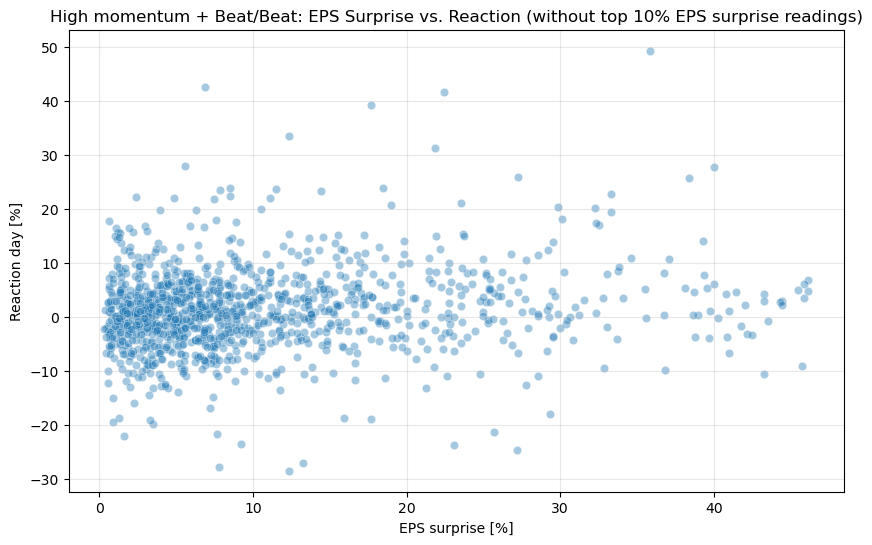

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=subset_filtered,
    x="EPS_surprise_pct",
    y="Reaction",
    alpha=0.4
)

plt.title("High momentum + Beat/Beat: EPS Surprise vs. Reaction (without top 10% EPS surprise readings)")
plt.xlabel("EPS surprise [%]")
plt.ylabel("Reaction day [%]")
plt.grid(alpha=0.3)

plt.show()

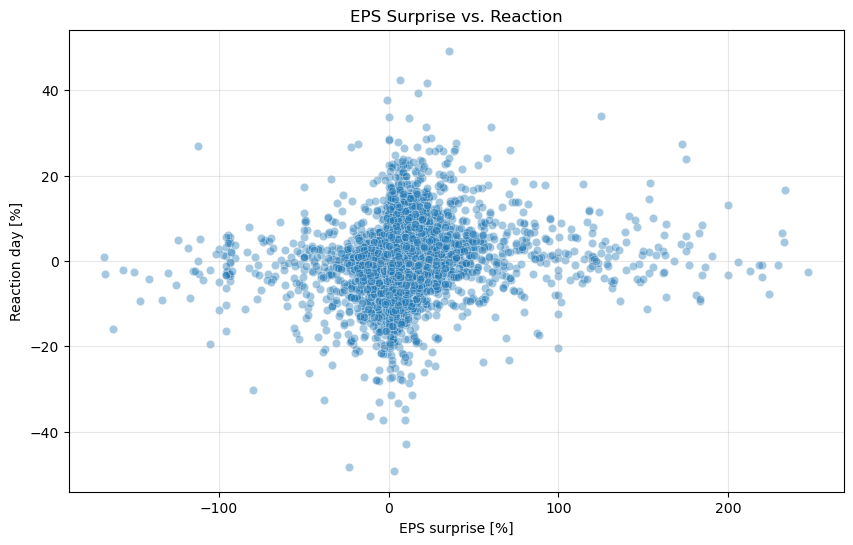

In [47]:
df_filtered2 = df[
    (df["EPS_surprise_pct"] > df["EPS_surprise_pct"].quantile(0.01)) &
    (df["EPS_surprise_pct"] < df["EPS_surprise_pct"].quantile(0.99))
]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered2,
    x="EPS_surprise_pct",
    y="Reaction",
    alpha=0.4
)

plt.title("EPS Surprise vs. Reaction")
plt.xlabel("EPS surprise [%]")
plt.ylabel("Reaction day [%]")
plt.grid(alpha=0.3)

plt.show()

In [49]:
plot_df["surprise_bin"] = plot_df["surprise_bin"].round(1)

In [51]:
bin_summary = subset.groupby("surprise_bin").agg(
    mean_reaction=("Reaction", "mean"),
    median_reaction=("Reaction", "median"),
    win_rate=("Reaction", lambda x: (x > 0).mean() * 100),
    observations=("Reaction", "count")
)

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\140383819.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = subset.groupby("surprise_bin").agg(


In [53]:
plot_df = bin_summary.reset_index().copy()
plot_df["surprise_bin"] = plot_df["surprise_bin"].astype(str)

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\651779453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = subset.groupby("surprise_bin").agg(


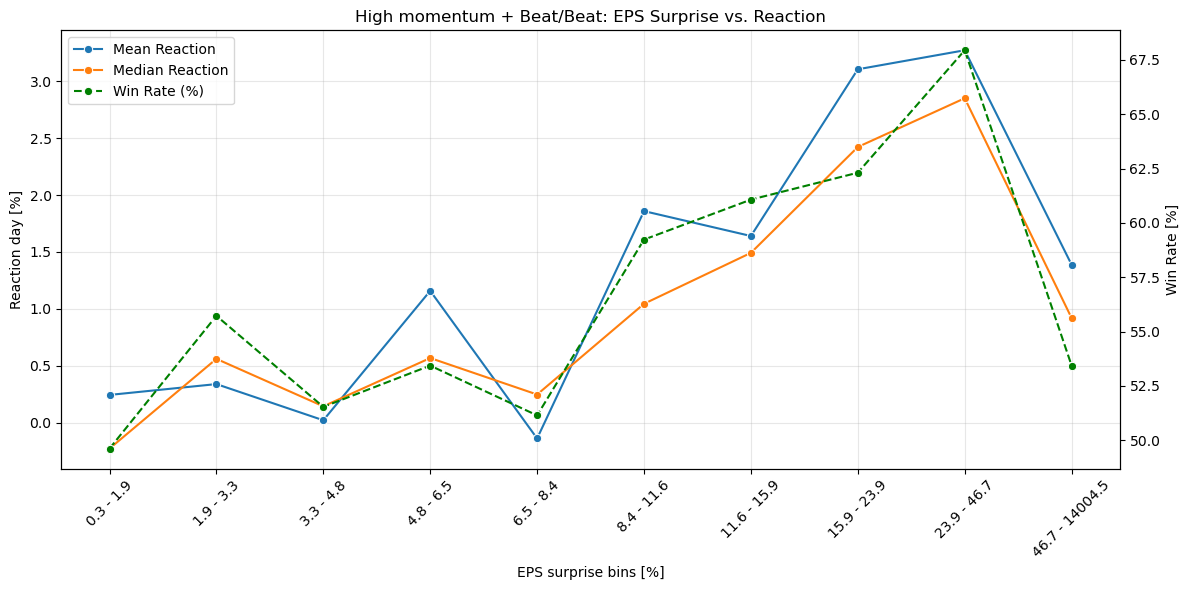

In [55]:
bin_summary = subset.groupby("surprise_bin").agg(
    mean_reaction=("Reaction", "mean"),
    median_reaction=("Reaction", "median"),
    win_rate=("Reaction", lambda x: (x > 0).mean() * 100),
    observations=("Reaction", "count")
)

plot_df = bin_summary.reset_index().copy()

plot_df["surprise_bin"] = plot_df["surprise_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = sns.lineplot(
    data=plot_df,
    x="surprise_bin",
    y="mean_reaction",
    marker="o",
    ax=ax1
)

line2 = sns.lineplot(
    data=plot_df,
    x="surprise_bin",
    y="median_reaction",
    marker="o",
    ax=ax1
)

ax1.set_ylabel("Reaction day [%]")
ax1.set_xlabel("EPS surprise bins [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=plot_df,
    x="surprise_bin",
    y="win_rate",
    marker="o",
    color="green",
    linestyle="--",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = ["Mean Reaction", "Median Reaction", "Win Rate (%)"]

ax1.legend(handles, labels, loc="upper left")

plt.title("High momentum + Beat/Beat: EPS Surprise vs. Reaction")
plt.tight_layout()
plt.show()

In [57]:
low_subset = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat") &
    (analysis_df["momentum_30d"] == "Low momentum")
].copy()

print(low_subset.shape)

(1228, 20)


In [59]:
subset = subset.replace([np.inf, -np.inf], np.nan)
subset = subset.dropna(subset=["EPS_surprise_pct"])

In [61]:
subset["surprise_bin"] = pd.qcut(
    subset["EPS_surprise_pct"],
    q=10,
    duplicates="drop"
)

(1228, 20)


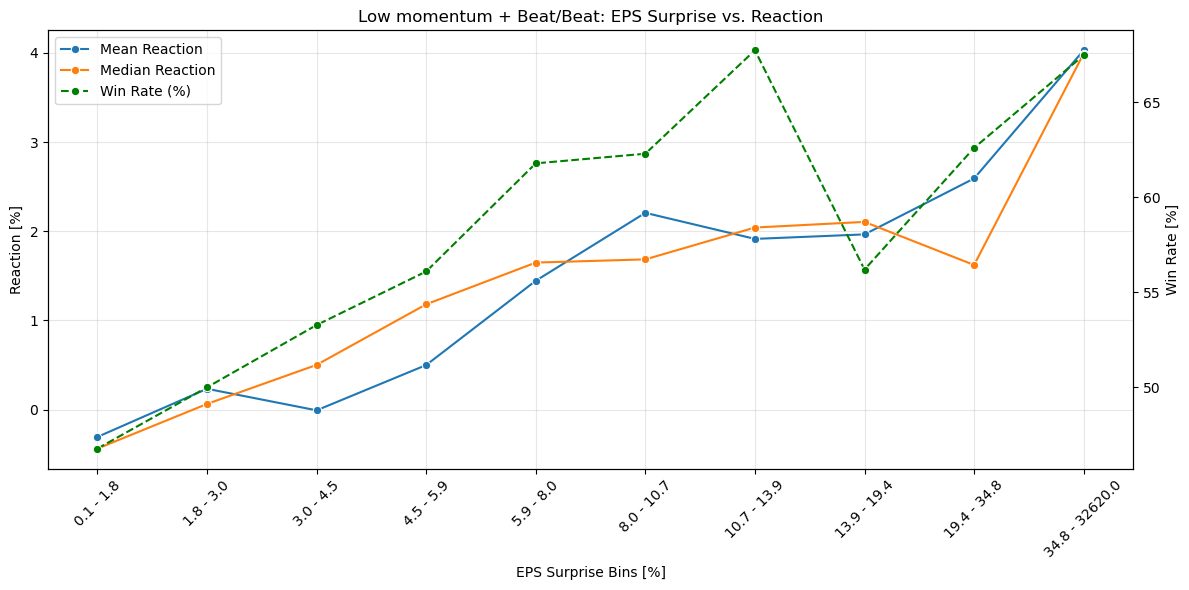

In [63]:
low_subset = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat") &
    (analysis_df["momentum_30d"] == "Low momentum")
].copy()

print(low_subset.shape)

low_subset = low_subset.replace([np.inf, -np.inf], np.nan)

low_subset = low_subset.dropna(
    subset=["EPS_surprise_pct", "Reaction"]
)

low_subset["surprise_bin"] = pd.qcut(
    low_subset["EPS_surprise_pct"],
    q=10,
    duplicates="drop"
)

bin_summary_low = low_subset.groupby(
    "surprise_bin",
    observed=False
).agg(
    mean_reaction=("Reaction", "mean"),
    median_reaction=("Reaction", "median"),
    win_rate=("Reaction", lambda x: (x > 0).mean() * 100),
    observations=("Reaction", "count")
)

plot_df_low = bin_summary_low.reset_index().copy()

plot_df_low["surprise_bin"] = plot_df_low["surprise_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=plot_df_low,
    x="surprise_bin",
    y="mean_reaction",
    marker="o",
    ax=ax1
)

sns.lineplot(
    data=plot_df_low,
    x="surprise_bin",
    y="median_reaction",
    marker="o",
    ax=ax1
)

ax1.set_xlabel("EPS Surprise Bins [%]")
ax1.set_ylabel("Reaction [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=plot_df_low,
    x="surprise_bin",
    y="win_rate",
    marker="o",
    linestyle="--",
    color="green",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = [
    "Mean Reaction",
    "Median Reaction",
    "Win Rate (%)"
]

ax1.legend(
    handles,
    labels,
    loc="upper left"
)

plt.title(
    "Low momentum + Beat/Beat: EPS Surprise vs. Reaction"
)

plt.tight_layout()
plt.show()

In [65]:
low_subset = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat") &
    (analysis_df["momentum_30d"] == "Low momentum")
].copy()

low_subset = low_subset.replace([np.inf, -np.inf], np.nan)
low_subset = low_subset.dropna(subset=["EPS_surprise_pct", "Reaction"])

low_subset = low_subset[
    (low_subset["EPS_surprise_pct"] < low_subset["EPS_surprise_pct"].quantile(0.99))
]

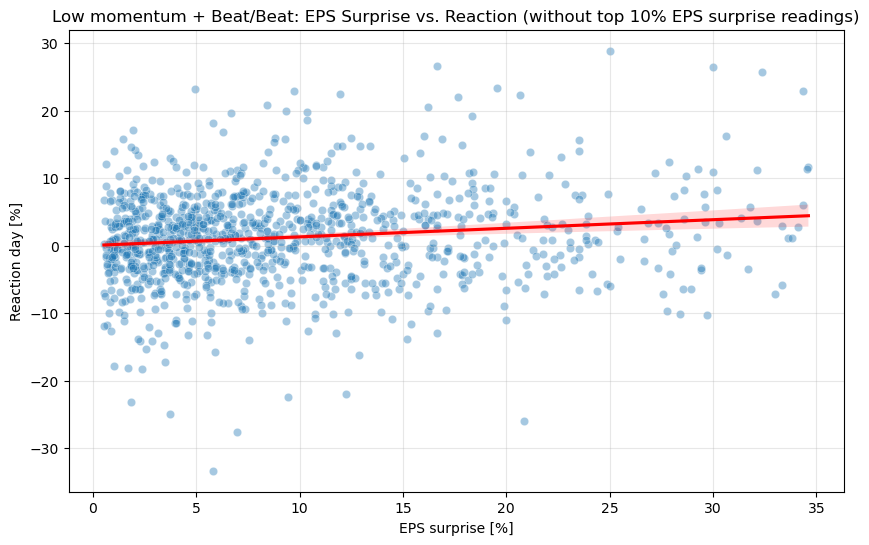

In [67]:
low_subset = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat") &
    (analysis_df["momentum_30d"] == "Low momentum")
].copy()

low_subset = low_subset.replace([np.inf, -np.inf], np.nan)
low_subset = low_subset.dropna(subset=["EPS_surprise_pct", "Reaction"])

eps_low = low_subset["EPS_surprise_pct"].quantile(0.01)
eps_high = low_subset["EPS_surprise_pct"].quantile(0.90)

low_subset = low_subset[
    (low_subset["EPS_surprise_pct"] >= eps_low) &
    (low_subset["EPS_surprise_pct"] <= eps_high)
]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=low_subset,
    x="EPS_surprise_pct",
    y="Reaction",
    alpha=0.4
)

sns.regplot(
    data=low_subset,
    x="EPS_surprise_pct",
    y="Reaction",
    scatter=False,
    color="red"
)

plt.title("Low momentum + Beat/Beat: EPS Surprise vs. Reaction (without top 10% EPS surprise readings)")
plt.xlabel("EPS surprise [%]")
plt.ylabel("Reaction day [%]")
plt.grid(alpha=0.3)

plt.show()

In [69]:
analysis_df = analysis_df.copy()

analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)
analysis_df = analysis_df.dropna(subset=["Pct_change_30d_before", "Reaction"])

analysis_df["momentum_bin"] = pd.qcut(
    analysis_df["Pct_change_30d_before"],
    q=10,
    duplicates="drop"
)

In [71]:
momentum_summary = (
    analysis_df.groupby("momentum_bin")
    .agg(
        observations=("Ticker", "count"),
        mean_reaction=("Reaction", "mean"),
        median_reaction=("Reaction", "median"),
        win_rate=("Reaction", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\464228992.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("momentum_bin")


In [73]:
plot_df = momentum_summary.copy()
plot_df["momentum_bin"] = plot_df["momentum_bin"].astype(str)

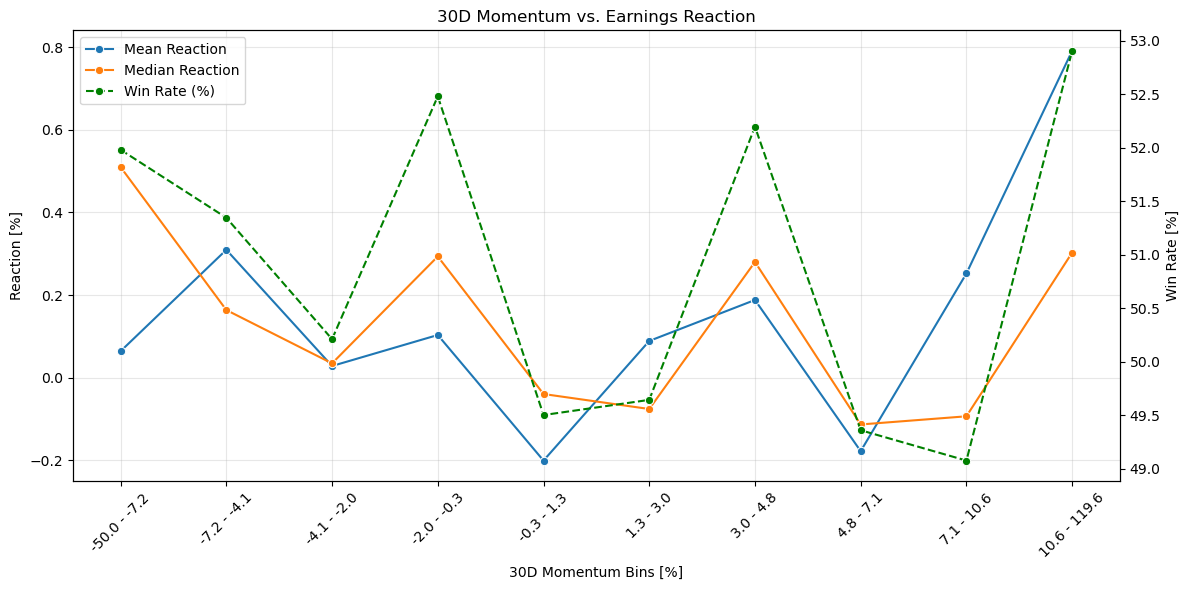

In [75]:
analysis_df = analysis_df.copy()

analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)

analysis_df = analysis_df.dropna(
    subset=["Pct_change_30d_before", "Reaction"]
)

analysis_df["momentum_bin"] = pd.qcut(
    analysis_df["Pct_change_30d_before"],
    q=10,
    duplicates="drop"
)

momentum_summary = (
    analysis_df
    .groupby("momentum_bin", observed=False)
    .agg(
        observations=("Ticker", "count"),
        mean_reaction=("Reaction", "mean"),
        median_reaction=("Reaction", "median"),
        win_rate=("Reaction", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

plot_df = momentum_summary.copy()

plot_df["momentum_bin"] = plot_df["momentum_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=plot_df,
    x="momentum_bin",
    y="mean_reaction",
    marker="o",
    ax=ax1
)

sns.lineplot(
    data=plot_df,
    x="momentum_bin",
    y="median_reaction",
    marker="o",
    ax=ax1
)

ax1.set_xlabel("30D Momentum Bins [%]")
ax1.set_ylabel("Reaction [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=plot_df,
    x="momentum_bin",
    y="win_rate",
    marker="o",
    linestyle="--",
    color="green",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = [
    "Mean Reaction",
    "Median Reaction",
    "Win Rate (%)"
]

ax1.legend(
    handles,
    labels,
    loc="upper left"
)

plt.title(
    "30D Momentum vs. Earnings Reaction"
)

plt.tight_layout()
plt.show()

In [77]:
bb = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat")
].copy()

bb = bb.replace([np.inf, -np.inf], np.nan)
bb = bb.dropna(subset=["Pct_change_30d_before", "Reaction"])

In [79]:
bb["momentum_bin"] = pd.qcut(
    bb["Pct_change_30d_before"],
    q=10,
    duplicates="drop"
)

In [81]:
bb_summary = (
    bb.groupby("momentum_bin")
    .agg(
        observations=("Ticker", "count"),
        mean_reaction=("Reaction", "mean"),
        median_reaction=("Reaction", "median"),
        win_rate=("Reaction", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

bb_summary["momentum_bin"] = bb_summary["momentum_bin"].astype(str)

C:\Users\lukas\AppData\Local\Temp\ipykernel_23060\107755361.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bb.groupby("momentum_bin")


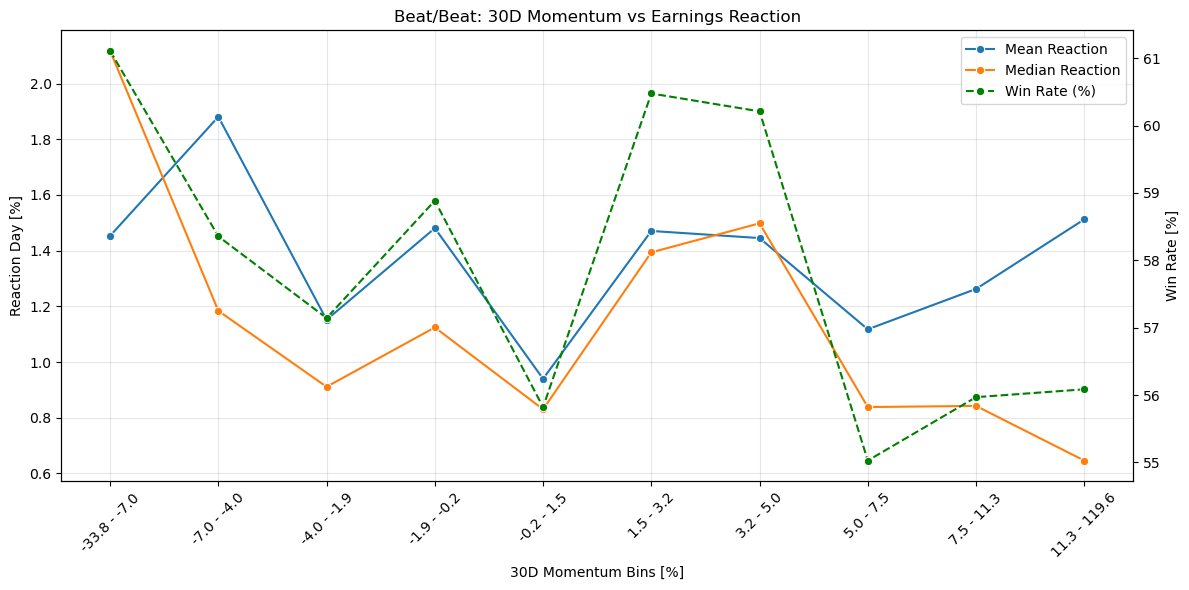

In [83]:
bb = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat")
].copy()

bb = bb.replace([np.inf, -np.inf], np.nan)

bb = bb.dropna(
    subset=["Pct_change_30d_before", "Reaction"]
)

bb["momentum_bin"] = pd.qcut(
    bb["Pct_change_30d_before"],
    q=10,
    duplicates="drop"
)

bb_summary = (
    bb.groupby("momentum_bin", observed=False)
    .agg(
        observations=("Ticker", "count"),
        mean_reaction=("Reaction", "mean"),
        median_reaction=("Reaction", "median"),
        win_rate=("Reaction", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

bb_summary["momentum_bin"] = bb_summary["momentum_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=bb_summary,
    x="momentum_bin",
    y="mean_reaction",
    marker="o",
    ax=ax1
)

sns.lineplot(
    data=bb_summary,
    x="momentum_bin",
    y="median_reaction",
    marker="o",
    ax=ax1
)

ax1.set_xlabel("30D Momentum Bins [%]")
ax1.set_ylabel("Reaction Day [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=bb_summary,
    x="momentum_bin",
    y="win_rate",
    marker="o",
    linestyle="--",
    color="green",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = [
    "Mean Reaction",
    "Median Reaction",
    "Win Rate (%)"
]

ax1.legend(
    handles,
    labels,
    loc="upper right"
)

plt.title(
    "Beat/Beat: 30D Momentum vs Earnings Reaction"
)

plt.tight_layout()
plt.show()


Reaction Day vs 30D Post-Earnings Performance

   reaction_bin  observations  mean_future_return  median_future_return  \
0  -49.1 - -7.8           673                1.28                  0.85   
1   -7.8 - -4.8           672                1.70                  1.09   
2   -4.8 - -2.8           672                1.24                  0.96   
3   -2.8 - -1.2           673                0.56                  0.51   
4    -1.2 - 0.1           672                1.13                  1.00   
5     0.1 - 1.5           672                0.87                  0.88   
6     1.5 - 3.1           673                1.28                  1.16   
7     3.1 - 4.9           672                1.36                  1.15   
8     4.9 - 7.9           672                1.38                  1.23   
9    7.9 - 49.2           673                2.53                  1.79   

   win_rate  
0     55.13  
1     56.40  
2     55.80  
3     52.30  
4     56.10  
5     55.21  
6     57.06  
7     57.59  


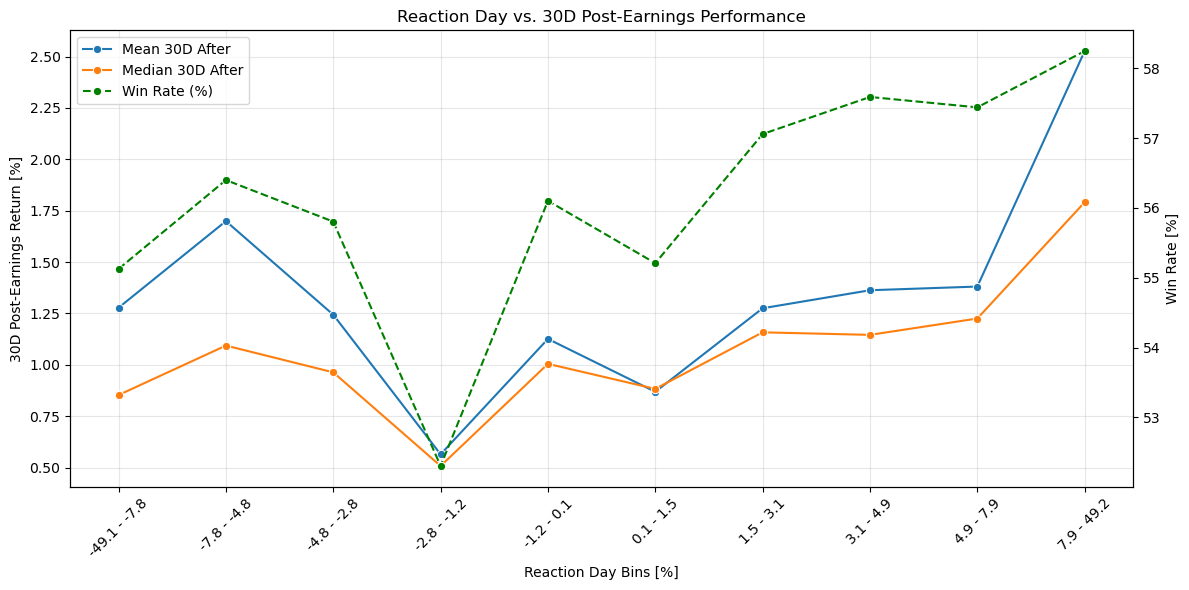

In [85]:
df = analysis_df.copy()

df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(
    subset=["Reaction", "Pct_change_30d_after"]
)

df["reaction_bin"] = pd.qcut(
    df["Reaction"],
    q=10,
    duplicates="drop"
)

reaction_summary = (
    df.groupby("reaction_bin", observed=False)
    .agg(
        observations=("Ticker", "count"),
        mean_future_return=("Pct_change_30d_after", "mean"),
        median_future_return=("Pct_change_30d_after", "median"),
        win_rate=("Pct_change_30d_after", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

reaction_summary["reaction_bin"] = reaction_summary["reaction_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

table_df = reaction_summary.copy()

table_df["mean_future_return"] = table_df["mean_future_return"].round(2)
table_df["median_future_return"] = table_df["median_future_return"].round(2)
table_df["win_rate"] = table_df["win_rate"].round(2)

print("\nReaction Day vs 30D Post-Earnings Performance\n")
print(table_df)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=reaction_summary,
    x="reaction_bin",
    y="mean_future_return",
    marker="o",
    ax=ax1
)

sns.lineplot(
    data=reaction_summary,
    x="reaction_bin",
    y="median_future_return",
    marker="o",
    ax=ax1
)

ax1.set_xlabel("Reaction Day Bins [%]")
ax1.set_ylabel("30D Post-Earnings Return [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=reaction_summary,
    x="reaction_bin",
    y="win_rate",
    marker="o",
    linestyle="--",
    color="green",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = [
    "Mean 30D After",
    "Median 30D After",
    "Win Rate (%)"
]

ax1.legend(
    handles,
    labels,
    loc="upper left"
)

plt.title(
    "Reaction Day vs. 30D Post-Earnings Performance"
)

plt.tight_layout()
plt.show()

In [87]:
df_all = analysis_df.copy()

df_all = df_all.replace([np.inf, -np.inf], np.nan)
df_all = df_all.dropna(subset=["Reaction", "Pct_change_30d_after"])

mean_reaction = df_all["Reaction"].mean()
median_reaction = df_all["Reaction"].median()

win_rate = (df_all["Pct_change_30d_after"] > 0).mean() * 100

mean_future = df_all["Pct_change_30d_after"].mean()
median_future = df_all["Pct_change_30d_after"].median()

print("=== OVERALL SAMPLE ===")
print(f"Observations: {len(df_all)}")

print("\n--- Reaction ---")
print(f"Mean Reaction:   {mean_reaction:.4f}")
print(f"Median Reaction: {median_reaction:.4f}")

print("\n--- 30D After ---")
print(f"Mean:            {mean_future:.4f}")
print(f"Median:          {median_future:.4f}")
print(f"Win Rate (>0):   {win_rate:.2f}%")

=== OVERALL SAMPLE ===
Observations: 6724

--- Reaction ---
Mean Reaction:   0.1190
Median Reaction: 0.1407

--- 30D After ---
Mean:            1.3326
Median:          1.0462
Win Rate (>0):   56.13%


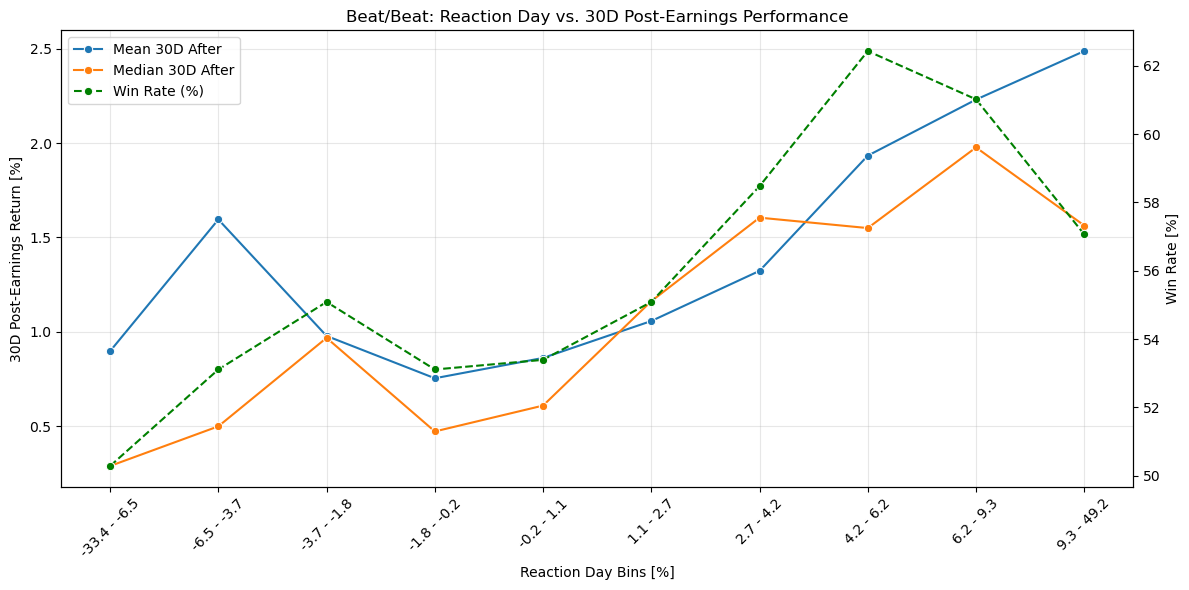

In [89]:
bb = analysis_df[
    (analysis_df["EPS_flag"] == "Beat") &
    (analysis_df["Revenue_flag"] == "Beat")
].copy()

bb = bb.replace([np.inf, -np.inf], np.nan)

bb = bb.dropna(
    subset=["Reaction", "Pct_change_30d_after"]
)

bb["reaction_bin"] = pd.qcut(
    bb["Reaction"],
    q=10,
    duplicates="drop"
)

bb_summary = (
    bb.groupby("reaction_bin", observed=False)
    .agg(
        observations=("Ticker", "count"),
        mean_future_return=("Pct_change_30d_after", "mean"),
        median_future_return=("Pct_change_30d_after", "median"),
        win_rate=("Pct_change_30d_after", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

bb_summary["reaction_bin"] = bb_summary["reaction_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=bb_summary,
    x="reaction_bin",
    y="mean_future_return",
    marker="o",
    ax=ax1
)

sns.lineplot(
    data=bb_summary,
    x="reaction_bin",
    y="median_future_return",
    marker="o",
    ax=ax1
)

ax1.set_xlabel("Reaction Day Bins [%]")
ax1.set_ylabel("30D Post-Earnings Return [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=bb_summary,
    x="reaction_bin",
    y="win_rate",
    marker="o",
    linestyle="--",
    color="green",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = [
    "Mean 30D After",
    "Median 30D After",
    "Win Rate (%)"
]

ax1.legend(
    handles,
    labels,
    loc="upper left"
)

plt.title("Beat/Beat: Reaction Day vs. 30D Post-Earnings Performance")
plt.tight_layout()
plt.show()

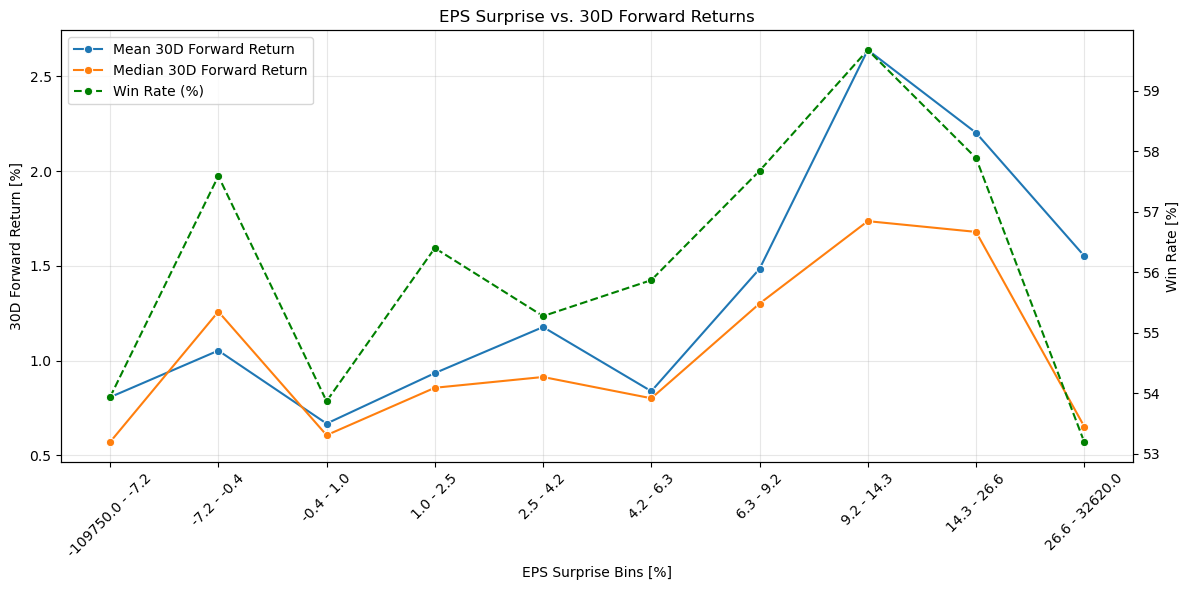

In [91]:
df = analysis_df.copy()

df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(
    subset=["EPS_surprise_pct", "Pct_change_30d_after"]
)

df["eps_bin"] = pd.qcut(
    df["EPS_surprise_pct"],
    q=10,
    duplicates="drop"
)

pead_summary = (
    df.groupby("eps_bin", observed=False)
    .agg(
        observations=("Ticker", "count"),
        mean_forward_30d=("Pct_change_30d_after", "mean"),
        median_forward_30d=("Pct_change_30d_after", "median"),
        win_rate=("Pct_change_30d_after", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

pead_summary["eps_bin"] = pead_summary["eps_bin"].apply(
    lambda x: f"{x.left:.1f} - {x.right:.1f}"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=pead_summary,
    x="eps_bin",
    y="mean_forward_30d",
    marker="o",
    ax=ax1
)

sns.lineplot(
    data=pead_summary,
    x="eps_bin",
    y="median_forward_30d",
    marker="o",
    ax=ax1
)

ax1.set_xlabel("EPS Surprise Bins [%]")
ax1.set_ylabel("30D Forward Return [%]")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

sns.lineplot(
    data=pead_summary,
    x="eps_bin",
    y="win_rate",
    marker="o",
    linestyle="--",
    color="green",
    ax=ax2,
    legend=False
)

ax2.set_ylabel("Win Rate [%]")

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

handles = [ax1.lines[0], ax1.lines[1], ax2.lines[0]]
labels = [
    "Mean 30D Forward Return",
    "Median 30D Forward Return",
    "Win Rate (%)"
]

ax1.legend(
    handles,
    labels,
    loc="upper left"
)

plt.title("EPS Surprise vs. 30D Forward Returns")
plt.tight_layout()
plt.show()

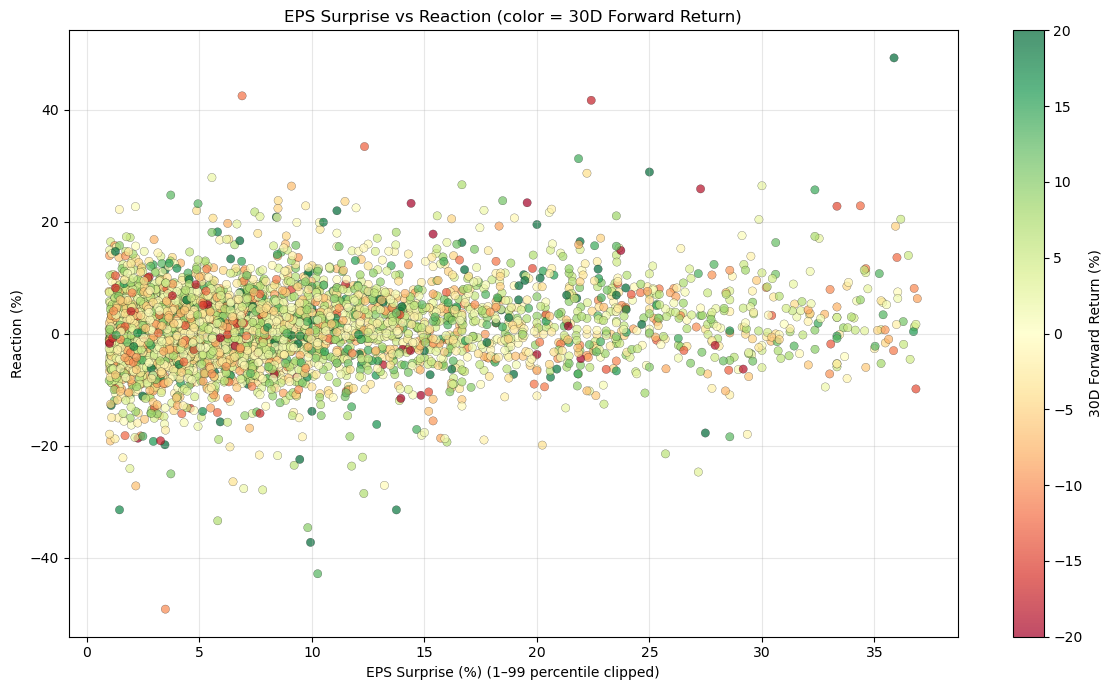

In [93]:
df = analysis_df.copy()

df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(
    subset=["EPS_surprise_pct", "Reaction", "Pct_change_30d_after"]
)

low_q = df["EPS_surprise_pct"].quantile(0.30)
high_q = df["EPS_surprise_pct"].quantile(0.93)

df = df[
    (df["EPS_surprise_pct"] >= low_q) &
    (df["EPS_surprise_pct"] <= high_q)
]

plt.figure(figsize=(12, 7))

sc = plt.scatter(
    df["EPS_surprise_pct"],
    df["Reaction"],
    c=df["Pct_change_30d_after"],
    cmap="RdYlGn",
    vmin=-20,
    vmax=20,
    alpha=0.7,
    edgecolor="k",
    linewidth=0.2
)

plt.xlabel("EPS Surprise (%) (1–99 percentile clipped)")
plt.ylabel("Reaction (%)")
plt.title("EPS Surprise vs Reaction (color = 30D Forward Return)")

plt.grid(alpha=0.3)

cbar = plt.colorbar(sc)
cbar.set_label("30D Forward Return (%)")

plt.tight_layout()
plt.show()